# E-Commerce Analytics — Exploratory Data Analysis

Explores the Olist Brazilian E-Commerce dataset via the dbt mart/KPI layer:
monthly revenue trend, seasonality, geographic distribution, category
performance, and delivery-time outliers.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

con = duckdb.connect("../warehouse/olist.duckdb", read_only=True)

## Monthly revenue trend

Dataset spans 23 distinct calendar months of delivered orders
(Sept 2016 – Oct 2018). A few early/late months are very sparse
(e.g. Dec 2016 has exactly 1 delivered order) — a real data quirk of
this dataset, not something to silently drop.

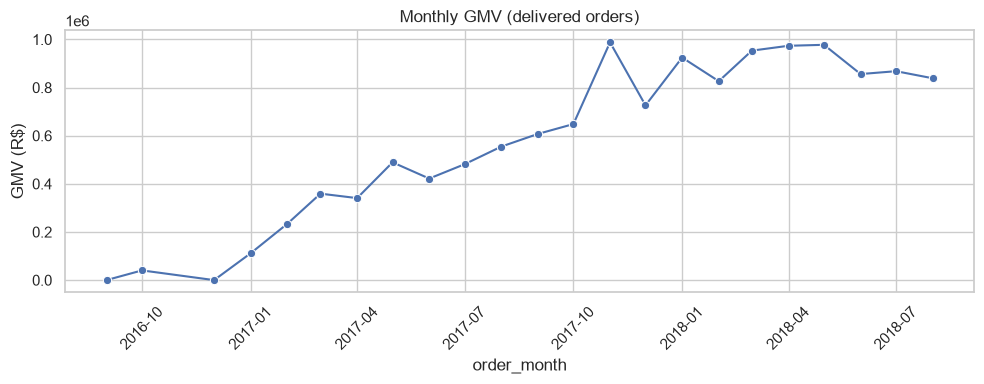

,order_month,order_count,gmv,average_order_value
18,2018-04-01,6798,973534.09,143.21
19,2018-05-01,6749,977544.69,144.84
20,2018-06-01,6099,856077.86,140.36
21,2018-07-01,6159,867953.46,140.92
22,2018-08-01,6351,838576.64,132.04


In [2]:
monthly_gmv = con.execute("select * from main.kpi_monthly_gmv order by order_month").fetchdf()

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=monthly_gmv, x="order_month", y="gmv", marker="o", ax=ax)
ax.set_title("Monthly GMV (delivered orders)")
ax.set_ylabel("GMV (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_gmv.tail()

## Seasonality: day of week and order value

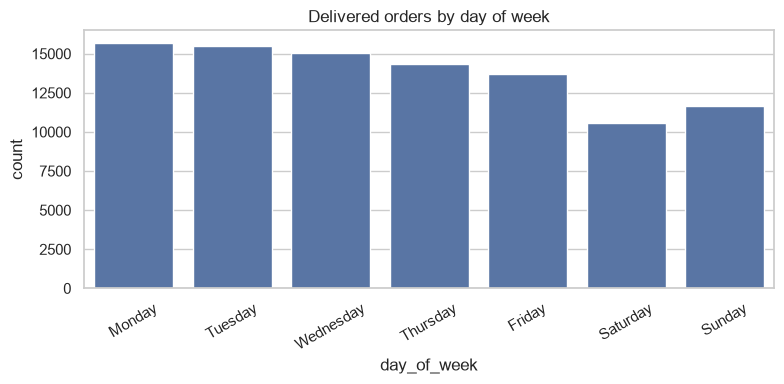

In [3]:
orders_df = con.execute("""
    select order_purchase_at, item_revenue, order_status
    from main.fct_orders
    where order_status = 'delivered'
""").fetchdf()

orders_df["day_of_week"] = orders_df["order_purchase_at"].dt.day_name()

fig, ax = plt.subplots(figsize=(8, 4))
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=orders_df, x="day_of_week", order=order, ax=ax)
ax.set_title("Delivered orders by day of week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Geographic distribution: GMV by state

São Paulo (SP) dominates GMV at roughly double the next-largest state.

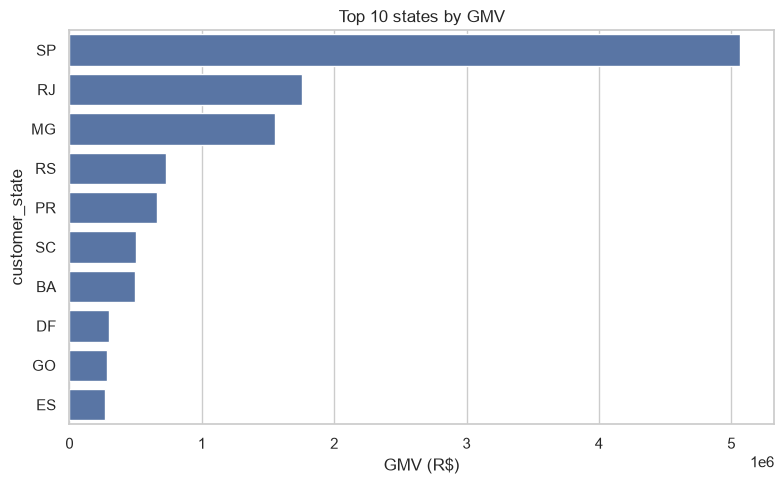

,customer_state,gmv,order_count
0,SP,5069547.64,40506
1,RJ,1759511.94,12351
2,MG,1552242.81,11351
3,RS,728977.47,5345
4,PR,665108.64,4921
5,SC,506710.13,3547
6,BA,493354.15,3254
7,DF,295697.71,2077
8,GO,283123.69,1956
9,ES,268733.35,1996


In [4]:
state_gmv = con.execute("""
    select c.customer_state, round(sum(o.item_revenue), 2) as gmv, count(*) as order_count
    from main.fct_orders o
    join main.dim_customers c on o.customer_unique_id = c.customer_unique_id
    where o.order_status = 'delivered'
    group by 1
    order by gmv desc
    limit 10
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=state_gmv, y="customer_state", x="gmv", ax=ax)
ax.set_title("Top 10 states by GMV")
ax.set_xlabel("GMV (R$)")
plt.tight_layout()
plt.show()

state_gmv

## Category performance: review score vs. order volume

Categories with fewer than 30 orders are excluded (`kpi_review_by_category`)
to avoid noisy small-sample averages.

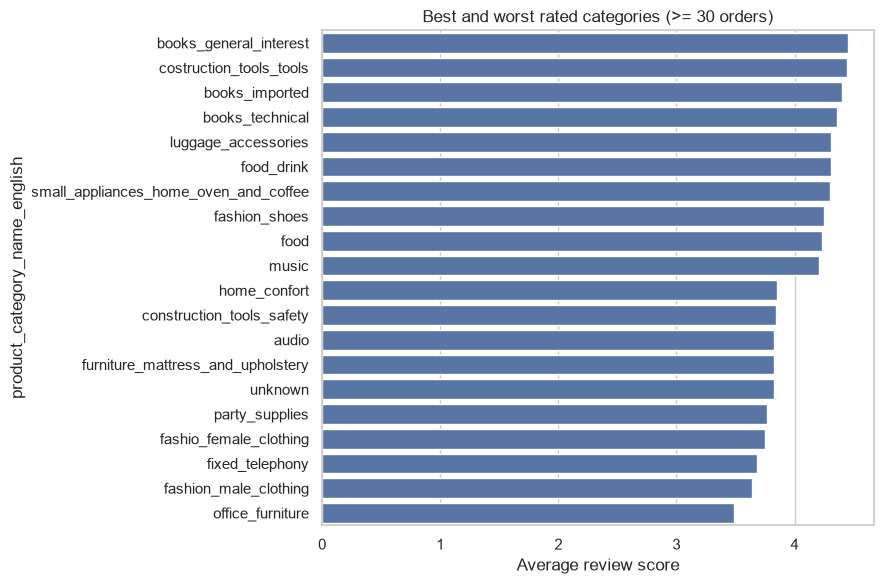

In [5]:
category_reviews = con.execute("select * from main.kpi_review_by_category order by average_review_score desc").fetchdf()

fig, ax = plt.subplots(figsize=(9, 6))
top_bottom = pd.concat([category_reviews.head(10), category_reviews.tail(10)])
sns.barplot(data=top_bottom, y="product_category_name_english", x="average_review_score", ax=ax)
ax.set_title("Best and worst rated categories (>= 30 orders)")
ax.set_xlabel("Average review score")
plt.tight_layout()
plt.show()

## Delivery time distribution and outliers

Verified stats: min 0 days, max 210 days, mean ~12.5, median 10, zero
negative values. The 210-day case is a genuine outlier worth flagging,
not a data error to filter out silently.

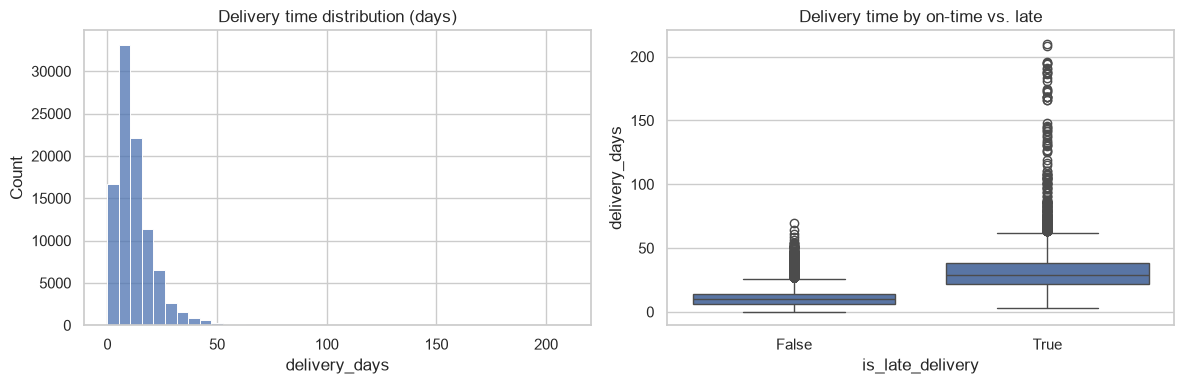

count    96476.000000
mean        12.497336
std          9.555460
min          0.000000
25%          7.000000
50%         10.000000
75%         16.000000
max        210.000000
Name: delivery_days, dtype: float64

In [6]:
delivery_df = con.execute("""
    select delivery_days, is_late_delivery
    from main.fct_orders
    where delivery_days is not null
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(delivery_df["delivery_days"], bins=40, ax=axes[0])
axes[0].set_title("Delivery time distribution (days)")

sns.boxplot(data=delivery_df, x="is_late_delivery", y="delivery_days", ax=axes[1])
axes[1].set_title("Delivery time by on-time vs. late")

plt.tight_layout()
plt.show()

delivery_df["delivery_days"].describe()

## Review score by delivery speed

Late deliveries average a 2.57 review score vs. 4.22 for on-time
deliveries — one of the strongest signals in this dataset, and the
basis for the quasi-experiment in Week 3.

In [7]:
con.execute("select * from main.kpi_review_by_delivery_speed order by is_late_delivery").fetchdf()

,is_late_delivery,order_count,average_review_score
0,False,90553,4.22
1,True,7614,2.57
